In [26]:
# 5장 회귀 - 실전 실습 - 자전거 대여 및 집값 에측

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

train = pd.read_csv("../data/bike_train.csv")
test = pd.read_csv("../data/bike_test.csv")

print(train.shape, test.shape)
train.info()

(10886, 12) (6493, 9)
<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


In [27]:
# datetime을 pd.to_datetime 타입으로 변환
train["datetime"] = pd.to_datetime(train["datetime"])
test["datetime"] = pd.to_datetime(test["datetime"])

train.dtypes

datetime      datetime64[us]
season                 int64
holiday                int64
workingday             int64
weather                int64
temp                 float64
atemp                float64
humidity               int64
windspeed            float64
casual                 int64
registered             int64
count                  int64
dtype: object

In [28]:
# 날짜를 년/월/일/시 로 쪼개서 새 peature 만들기
train["year"] = train.datetime.apply(lambda x: x.year)
train["month"] = train.datetime.apply(lambda x: x.month)
train["day"] = train.datetime.apply(lambda x: x.day)
train["hour"] = train.datetime.apply(lambda x: x.hour)

test["year"] = test.datetime.apply(lambda x: x.year)
test["month"] = test.datetime.apply(lambda x: x.month)
test["day"] = test.datetime.apply(lambda x: x.day)
test["hour"] = test.datetime.apply(lambda x: x.hour)

train[["datetime", "year", "month", "day", "hour"]].head()

,datetime,year,month,day,hour
0,2011-01-01 00:00:00,2011,1,1,0
1,2011-01-01 01:00:00,2011,1,1,1
2,2011-01-01 02:00:00,2011,1,1,2
3,2011-01-01 03:00:00,2011,1,1,3
4,2011-01-01 04:00:00,2011,1,1,4


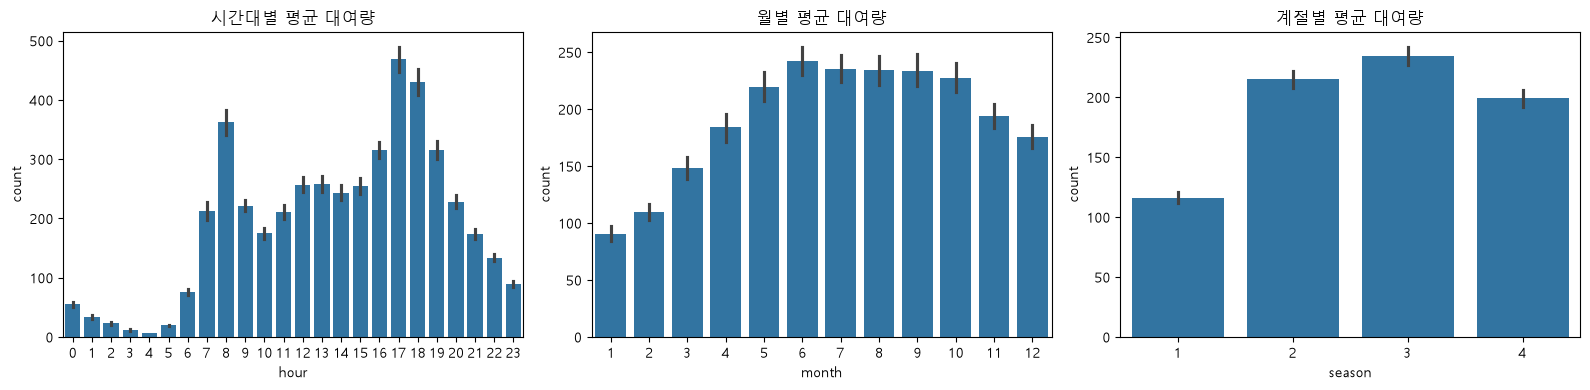

In [ ]:
# 한글 안깨지게 하기위함
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

fig, axs = plt.subplots(figsize = (16, 4), ncols =3)

sns.barplot(x = 'hour', y = 'count', data = train, ax = axs[0])
axs[0].set_title("시간대별 평균 대여량")

sns.barplot(x = "month", y = "count", data = train, ax = axs[1])
axs[1].set_title("월별 평균 대여량")

sns.barplot(x="season", y="count", data = train, ax = axs[2])
axs[2].set_title("계절별 평균 대여량")

plt.tight_layout()
plt.show()

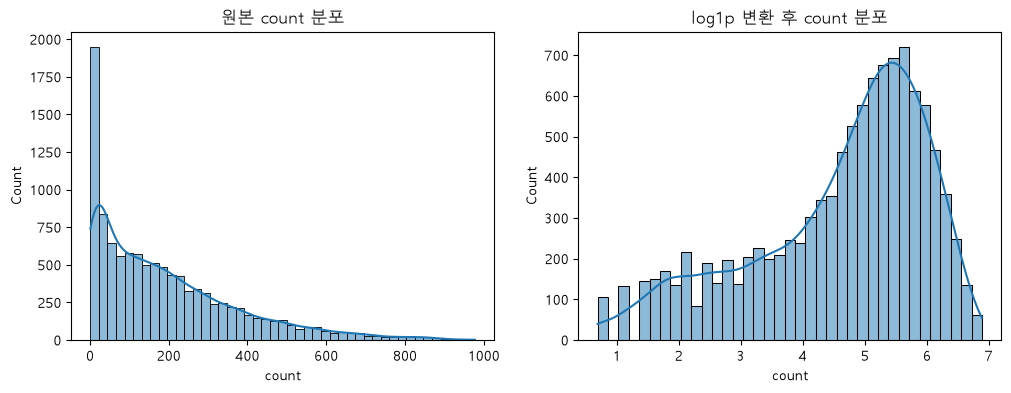

In [36]:
fig, axs = plt.subplots(figsize = (12, 4), ncols = 2)

sns.histplot(train["count"], ax = axs[0], kde = True)
axs[0].set_title("원본 count 분포")

sns.histplot(np.log1p(train["count"]), ax = axs[1], kde = True)
axs[1].set_title("log1p 변환 후 count 분포")

plt.show()

In [30]:
drop_cols = ["datetime", "casual", "registered"]

X_features = train.drop(["count"] + drop_cols, axis = 1)
y_target = train["count"]
X_test_final = test.drop(["datetime"], axis = 1)

print(X_features.columns.tolist())
print(X_test_final.columns.tolist())

['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'year', 'month', 'day', 'hour']
['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'year', 'month', 'day', 'hour']


In [31]:
y_log = np.log1p(y_target)

In [32]:
def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, a_min = 0, a_max = None) #음수가 없으니까 예측못하게하기
    log_true = np.log1p(y_true)
    log_pred = np.log1p(y_pred)
    return np.sqrt(mean_squared_error(log_true, log_pred))

def evaluate_regr(y_true, y_pred):
    rmsle_val = rmsle(y_true, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_val = mean_absolute_error(y_true, y_pred)
    print(f"RMSLE: {rmsle_val:.4f}, RMSE: {rmse_val:.4f}, MAE: {mae_val:.4f}")

In [33]:
X_train, X_val, y_train_log, y_val_log = train_test_split(X_features,
                                                          y_log,
                                                          test_size = 0.3,
                                                          random_state = 42)

lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train_log)

pred_log = lr_reg.predict(X_val)

# 로그 스케일 학습 > expm1사용 원래 단위 복원 후 평가
pred = np.expm1(pred_log)
y_val = np.expm1(y_val_log)
evaluate_regr(y_val, pred)

RMSLE: 1.0202, RMSE: 160.7296, MAE: 108.2357


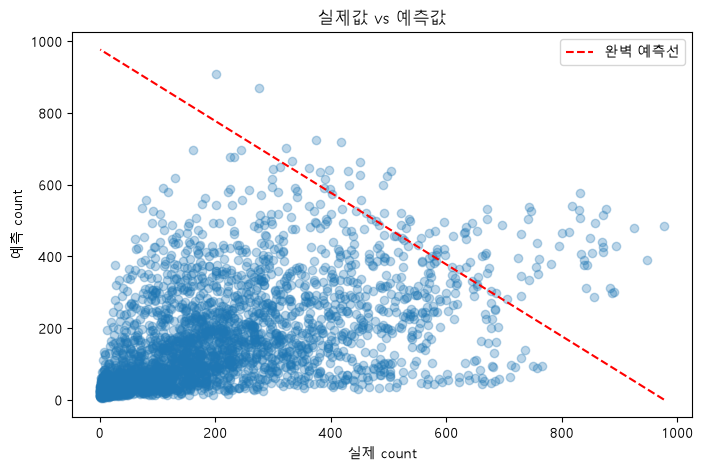

In [38]:
plt.figure(figsize = (8, 5))
plt.scatter(y_val, pred, alpha = 0.3)
plt.plot([y_val.max(), y_val.min()],
         [y_val.min(), y_val.max()],
         "r--",
         label="완벽 예측선")
plt.xlabel("실제 count")
plt.ylabel("예측 count")
plt.title("실제값 vs 예측값")
plt.legend()
plt.show()


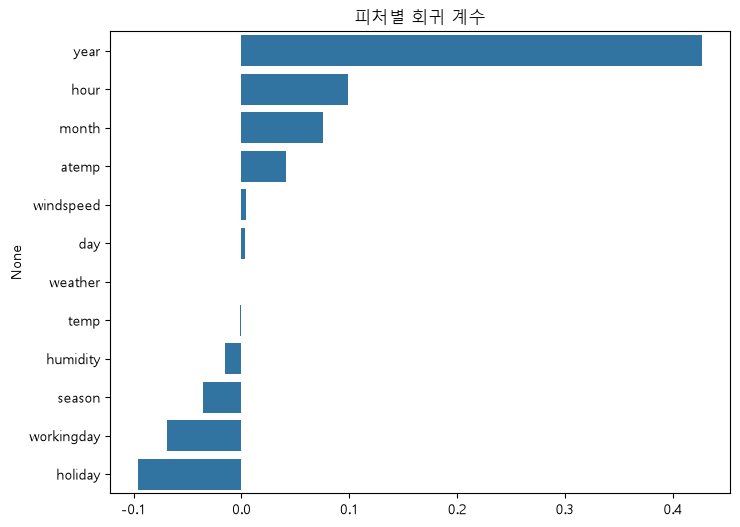

In [39]:
coef_series = pd.Series(lr_reg.coef_, index = X_features.columns)
coef_series = coef_series.sort_values(ascending = False)

plt.figure(figsize = (8, 6))
sns.barplot(x = coef_series.values,
            y = coef_series.index)
plt.title("피처별 회귀 계수")
plt.show()

In [34]:
final_pred_log = lr_reg.predict(X_test_final)
final_pred = np.expm1(final_pred_log)

submission = pd.DataFrame({"datetime": test["datetime"],
                           "count": final_pred})

submission.head()

,datetime,count
0,2011-01-20 00:00:00,11.450331
1,2011-01-20 01:00:00,12.663866
2,2011-01-20 02:00:00,14.084896
3,2011-01-20 03:00:00,15.838241
4,2011-01-20 04:00:00,17.589404
